In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append(r'C:\Chimera\B240_data_analysis\Library\ChimeraGenTools')


import AnalysisHelpers as ah
import MatplotlibPlotters as mp
from fitters import linear

I am imported expfile
I am imported Miscellaneous


(1, 37, 2)
(1, 37)
[116.24562363 115.25920146 114.25486024 113.27275427 112.27225719
 111.28219103 110.29477089 109.30724789 108.29842719 107.29989329
 106.30402388 105.31965012 104.30599082 103.29909407 102.31066172
 101.32105184 100.31851425  99.30417861  98.32152523  97.31663508
  96.292429    95.31716787  94.31788055  93.31465534  92.30821637
  91.30707432  90.28977481  89.2991689   88.29834627  87.29995424
  86.28900054  85.27622176  84.28181393  83.27483878  82.26911607
  81.2480747   80.26759257]
Slope: -9.9995(68)e-01
Offset: 1.16293(14)e+02
rounded p = [-1.0, 116.29252154367704]


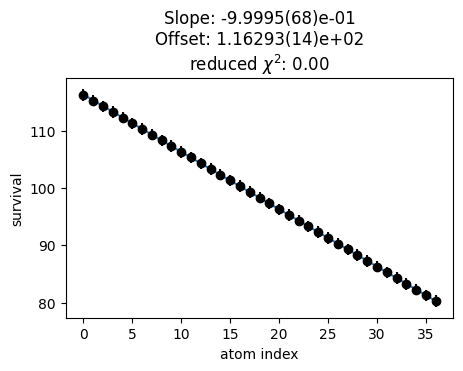

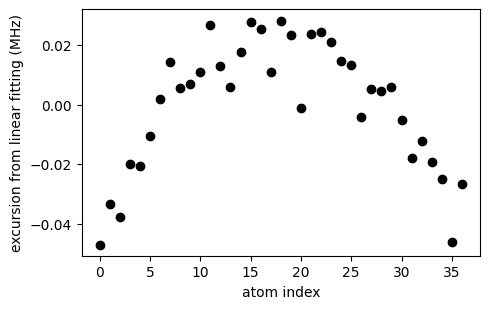

[[[ 0.04689637  0.        ]
  [ 0.03336854 -0.00219678]
  [ 0.03775976 -0.00394662]
  [ 0.01991573  0.00082404]
  [ 0.02046281  0.00198517]
  [ 0.01057897 -0.00347427]
  [-0.00195089 -0.00686775]
  [-0.01437789 -0.00171241]
  [-0.00550719 -0.0032452 ]
  [-0.00692329 -0.0019181 ]
  [-0.01100388 -0.00407313]
  [-0.02658012 -0.00018436]
  [-0.01287082 -0.00416439]
  [-0.00592407 -0.00148734]
  [-0.01744172 -0.00517406]
  [-0.02778184 -0.00142316]
  [-0.02519425 -0.00896047]
  [-0.01080861 -0.00077537]
  [-0.02810523 -0.00047736]
  [-0.02316508 -0.0033808 ]
  [ 0.001091   -0.00235787]
  [-0.02359787 -0.00767503]
  [-0.02426055 -0.00620018]
  [-0.02098534 -0.01171363]
  [-0.01449637 -0.01045047]
  [-0.01330432 -0.00920416]
  [ 0.00404519 -0.00891406]
  [-0.0052989  -0.00747095]
  [-0.00442627 -0.01164229]
  [-0.00598424 -0.01024425]
  [ 0.00501946 -0.00796128]
  [ 0.01784824 -0.013837  ]
  [ 0.01230607 -0.01041718]
  [ 0.01933122 -0.01541612]
  [ 0.02510393 -0.01437705]
  [ 0.0461953  -0.01

In [3]:

freqLUT = np.load('./freqLUT_20251208_data2.npy')
print(freqLUT.shape)
gridShape = freqLUT.shape[:2]

print(gridShape)
print(freqLUT[0,:,0])

x_grid_idx,x_freq = np.arange(gridShape[1]), freqLUT[0,:,0]
function = linear
p0 = None
punc,p,_ = ah.fit_data(x_grid_idx,x_freq, fit_function=function, use_unc=False)

x,y = x_grid_idx,x_freq
fig,ax = mp._plotStandard1D(x,y,exp_file=None, fitb=True, fit_function=function,
                                guess=p0, ignore_zero_unc=True, use_unc=False, plot_guess=False, fit_result_on_title=True, data_name_newline=True, ylim=None)
ax.set_title(ax.get_title())
ax.set_xlabel('atom index')
ax.set_ylabel('survival')
print(f'rounded p = [{np.round(p[0],3)}, {p[1]}]')
plt.show()
p = [np.round(p[0],5), p[1]]

x,y = x_grid_idx,x_freq-linear.f(x_grid_idx, *p)
fig,ax = mp._plotStandard1D(x,y,np.zeros_like(y),exp_file=None, fitb=False, fit_function=function,
                                guess=p0, ignore_zero_unc=True, use_unc=False, plot_guess=False, fit_result_on_title=True, data_name_newline=True, ylim=None)
ax.set_title(ax.get_title())
ax.set_xlabel('atom index')
ax.set_ylabel('excursion from linear fitting (MHz)')
fig.tight_layout()
mp.GoldenRatio(fig)
plt.show()

freqLUT_new = np.zeros_like(freqLUT)
freqLUT_new[0,:,0] = np.round(linear.f(x_grid_idx, *p), 5)
# freqLUT_new[0,:,1] = np.round(freqLUT[0,:,1].mean(), 5)
freqLUT_new[0,:,1] = np.repeat(freqLUT[0,0,1], gridShape[0])

print(freqLUT_new-freqLUT)
print(freqLUT_new.shape)
# np.save('./freqLUT_uniform_spacing.npy', freqLUT_new)
# freqLUT = freqLUT.reshape(*pts_Marana_SLM.shape)
# freqLUT.shape